Load all Libraries

In [1]:
import random
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from keras.models import Sequential
from keras.layers import Input, Conv1D, Dropout, Flatten, Dense
from keras.utils import to_categorical
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
#Set seed
SEED = 123
random.seed(SEED)
np.random.seed(SEED)

Declare all global variables

In [2]:
# 1) Path to CSV file
DATASET_PATH = Path("../Datasets/Final_Modelling_Dataset.csv")

# 2) Target column name
TARGET_VARIABLE = "Alzheimer.s.Diagnosis"

# 3) Columns to drop before analysis (IDs / metadata). Keep as a Python list.
EXCLUDE_COLUMNS = []  # e.g., ["ID", "RecordNo"]

# 4) Output folder (created if missing)
OUTDIR = Path("../All Reports/4. Supervised ML and DL Reports")
OUTDIR.mkdir(parents=True, exist_ok=True)

# 4) All Results Output folder (created if missing)
OUTDIR_Final = Path("../All Reports/5. All Final Result")
OUTDIR_Final.mkdir(parents=True, exist_ok=True)

# 5) Cross Validation Result on the best model
OUTDIR_CV = Path("../All Reports/6. 10 Fold Cross Validation")
OUTDIR_CV.mkdir(parents=True, exist_ok=True)

Import the data

In [3]:
# Function to load a CSV file into a pandas DataFrame
def load_data(path):
    return pd.read_csv(
        path,
        # Explicit NA values for blanks, "NA", and spaces
        na_values=["", "NA", " "],
        # Prevent Pandas from treating "None" (and other strings) as missing
        keep_default_na=False
    )

# Load and inspect using the configured path
df = load_data(DATASET_PATH)

Binarizes the target: maps 'No'/'Yes' to 0/1 on a copy (Int8 dtype) and returns it, the call applies this to `df`.

In [4]:
def binarize_target_simple(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """
    Convert a binary target column with 'Yes'/'No' to {0,1}.
    Returns a new DataFrame with the converted column.
    """
    mapping = {"No": 0, "Yes": 1}
    out = df.copy()
    out[target_col] = out[target_col].map(mapping).astype("Int8")
    return out

# Usage
df = binarize_target_simple(df, TARGET_VARIABLE)

Stratified holdout split with exact class balance: samples within each class to form an 80/20, train/test split, shuffles both, prints sizes and class proportions, and returns the frames, the call below uses a 20% test size.

In [5]:
def stratified_train_test_split_exact(df, target_col, test_size=0.2, random_state=SEED):
    """
    Splits the dataset into 2 DataFrames: train (80%) and test (20%),
    with exact 50/50 balance of the binary target in both splits.
    """
    np.random.seed(random_state)

    # Separate by class
    df0 = df[df[target_col] == 0]
    df1 = df[df[target_col] == 1]

    # Split each class
    train0 = df0.sample(frac=1 - test_size, random_state=random_state)
    test0 = df0.drop(train0.index)

    train1 = df1.sample(frac=1 - test_size, random_state=random_state)
    test1 = df1.drop(train1.index)

    # Combine and shuffle
    train_df = pd.concat([train0, train1]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    test_df  = pd.concat([test0, test1]).sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Print stats
    print(f"Train size: {train_df.shape}, Test size: {test_df.shape}")
    print("Train distribution:", train_df[target_col].value_counts(normalize=True).to_dict())
    print("Test distribution: ", test_df[target_col].value_counts(normalize=True).to_dict())

    return train_df, test_df

# Usage
train_df, test_df = stratified_train_test_split_exact(df, TARGET_VARIABLE, test_size=0.2)

Train size: (5216, 55), Test size: (1304, 55)
Train distribution: {np.int8(0): 0.5, np.int8(1): 0.5}
Test distribution:  {np.int8(1): 0.5, np.int8(0): 0.5}


Scales continuous features for scale-sensitive models (NN, SVM, Logistic Regression, CNN), fit Standard/MinMax scaler on train only, apply to test. Leave 0/1 binaries and the target untouched.

In [6]:
def scale_train_test_with_target(
    train_df, test_df, target_col, exclude_cols=None, scaler_type="standard"
):
    """
    Takes pre-split train_df and test_df.
    Scales continuous numeric features with StandardScaler or MinMaxScaler.
    Leaves binary (0/1) features and target untouched.

    Returns:
        train_scaled (DataFrame with target_col),
        test_scaled  (DataFrame with target_col),
        scaler
    """
    if exclude_cols is None:
        exclude_cols = []
        
    # Separate features/target
    drop_cols = [target_col, *exclude_cols]
    X_train = train_df.drop(columns=drop_cols, errors="ignore")
    y_train = train_df[target_col]
    X_test  = test_df.drop(columns=drop_cols, errors="ignore")
    y_test  = test_df[target_col]
    
    # Identify numeric columns
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    # Binary check helper
    def _is_binary(col):
        vals = X_train[col].dropna().unique()
        return len(vals) <= 2 and set(vals).issubset({0,1})
    
    binary_cols = [c for c in num_cols if _is_binary(c)]
    scaled_cols = [c for c in num_cols if c not in binary_cols]

    # Choose scaler
    scaler = StandardScaler() if scaler_type=="standard" else MinMaxScaler()

    # Scale continuous cols only
    X_train_scaled = X_train.copy()
    X_test_scaled  = X_test.copy()
    if scaled_cols:
        scaler.fit(X_train[scaled_cols])   # fit on train only
        X_train_scaled[scaled_cols] = scaler.transform(X_train[scaled_cols])
        X_test_scaled[scaled_cols]  = scaler.transform(X_test[scaled_cols])

    # Reattach target
    train_scaled = X_train_scaled.copy()
    train_scaled[target_col] = y_train.values
    test_scaled = X_test_scaled.copy()
    test_scaled[target_col] = y_test.values

    # Print summary
    print(f"Train shape: {train_scaled.shape}, Test shape: {test_scaled.shape}")
    print(f"Scaled columns ({scaler_type}): {scaled_cols}")
    print(f"Binary columns (not scaled): {binary_cols}")

    return train_scaled, test_scaled, scaler


# Usage
train_scaled, test_scaled, scaler = scale_train_test_with_target(
    train_df, test_df, target_col=TARGET_VARIABLE, scaler_type="standard"
)


Train shape: (5216, 55), Test shape: (1304, 55)
Scaled columns (standard): ['Age', 'BMI', 'Alcohol.Consumption.NUM', 'Physical.Activity.NUM', 'Diet.Quality.NUM', 'Sleep.Quality.NUM', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL', 'Cognitive.Test.Score', 'EducationLevel', 'Physical.Activity.CAT', 'Smoking.Status', 'Alcohol.Consumption.CAT', 'Depression.Level', 'Sleep.Quality.CAT', 'Diet.Quality.CAT', 'Air.Pollution.Exposure', 'Social.Engagement.Level', 'Income.Level', 'Stress.Levels']
Binary columns (not scaled): ['Gender', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Cholesterol.Level', 'Genetic.Risk.Factor..APOE.ε4.allele.', 'Ethnicity_African American', 'Ethnicity_Asian', 'Ethnicity_Caucasian'

Neural Network

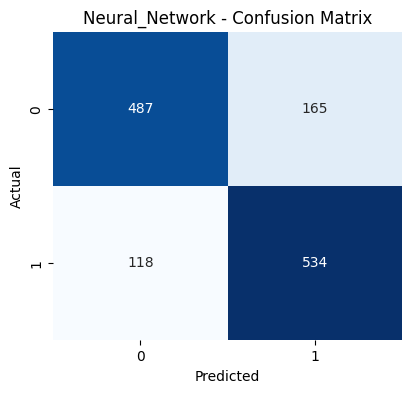

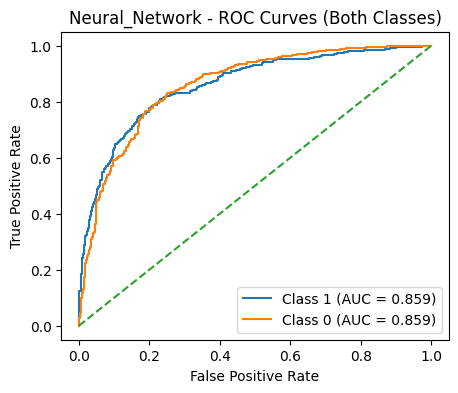

Neural Network (Pipeline 1) accuracy: 0.7829754601226994


In [7]:
def neural_network_classifier(
    train_df,
    test_df,
    target_col,
    pipeline_name="pipeline_original",
    outdir=OUTDIR,
):
    """
    Train a fixed-setup MLP (Neural Network) on train_df and evaluate on test_df.
    Saves under: <outdir>/<pipeline_name>/NeuralNetwork/
    Returns a dict with accuracy and report paths.
    """
    model_name = "Neural_Network"
    model_dir = Path(outdir) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) Split X/y
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].astype(int)

    # 2) Model setup
    clf = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate="adaptive",
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=SEED,
    )
    clf.fit(X_train, y_train)

    # 3) Predict labels + scores
    y_pred = clf.predict(X_test)
    if hasattr(clf, "predict_proba"):
        proba   = clf.predict_proba(X_test)
        y_score1 = proba[:, 1]  # class 1 scores
        y_score0 = proba[:, 0]  # class 0 scores
    else:
        # Fallback: decision_function, use scores to represent the two classes
        dec = clf.decision_function(X_test)
        y_score1 = dec
        y_score0 = -dec

    # 4) Metrics table
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision & F1 (no "recall" column in CSV)
    prec, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    # Confusion matrix for counts
    cm_eval = confusion_matrix(y_test, y_pred, labels=[0, 1])
    # cm with labels=[0,1]:
    # [[TN, FP],
    #  [FN, TP]]
    TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
    FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

    # Treat class 0 as "positive" for class-0 metrics
    TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
    FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

    def safe_div(n, d): return float(n) / d if d else 0.0

    # TPR (Sensitivity) and TNR (Specificity) per class
    tpr0 = safe_div(TP0, TP0 + FN0)   # class 0 sensitivity
    tnr0 = safe_div(TN0, TN0 + FP0)   # class 0 specificity
    tpr1 = safe_div(TP1, TP1 + FN1)   # class 1 sensitivity
    tnr1 = safe_div(TN1, TN1 + FP1)   # class 1 specificity

    # Cohen's Kappa (manual)
    N = cm_eval.sum()
    po = acc
    r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
    c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
    pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
    kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

    # AUC values (each class as positive)
    auc1 = roc_auc_score(y_test, y_score1)       # AUC - class 1
    auc0 = roc_auc_score(1 - y_test, y_score0)   # AUC - class 0

    metrics_df = pd.DataFrame({
        "metric": [
            # Overall
            "Accuracy",
            "Cohen's Kappa",

            # Class 0 counts
            "True Positive (TP) - class 0",
            "True Negative (TN) - class 0",
            "False Positive (FP) - class 0",
            "False Negative (FN) - class 0",
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0",
            "True Negative Rate (TNR) / Specificity - class 0",
            "Precision - class 0",
            "F1 Score - class 0",

            # Class 1 counts
            "True Positive (TP) - class 1",
            "True Negative (TN) - class 1",
            "False Positive (FP) - class 1",
            "False Negative (FN) - class 1",
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1",
            "True Negative Rate (TNR) / Specificity - class 1",
            "Precision - class 1",
            "F1 Score - class 1",

            # AUCs (ROC curve is plotted separately)
            "AUC - class 0",
            "AUC - class 1",
        ],
        "value": [
            acc,
            kappa,

            # Class 0 counts
            TP0, TN0, FP0, FN0,
            # Class 0 rates/metrics
            tpr0, tnr0, prec[0], f1[0],

            # Class 1 counts
            TP1, TN1, FP1, FN1,
            # Class 1 rates/metrics
            tpr1, tnr1, prec[1], f1[1],

            # AUCs
            auc0, auc1,
        ]
    })
    metrics_csv = model_dir / "metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    # classification report (text)
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y_test, y_pred, digits=4))

    # 5) Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    cm_jpg = model_dir / "confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # 6) ROC curve (show both classes)
    fpr1, tpr1, _ = roc_curve(y_test, y_score1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y_test, y_score0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "model": clf,
        "accuracy": acc,
        "metrics_csv": str(metrics_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
    }

# Usage: Pipeline 1 (original dataset)
nn_out_orig = neural_network_classifier(
    train_scaled,
    test_scaled,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_original_data"
)
print("Neural Network (Pipeline 1) accuracy:", nn_out_orig["accuracy"])


SVM Polynomial Kernel

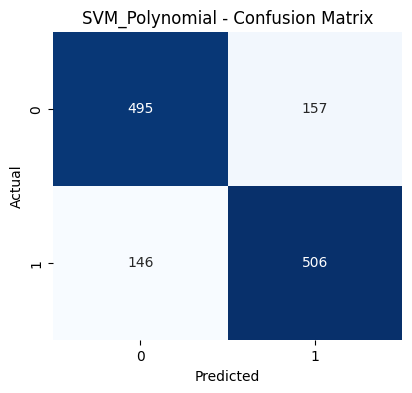

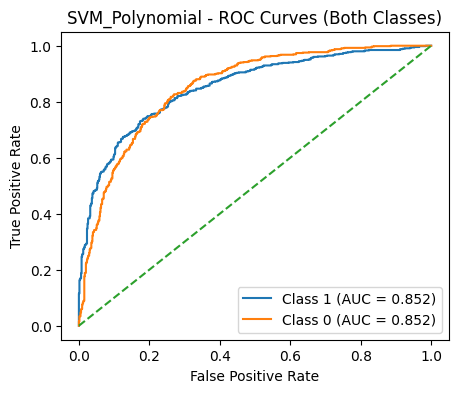

SVM-Poly (Pipeline 1) accuracy: 0.7676380368098159


In [8]:
def svm_polynomial_classifier(
    train_df,
    test_df,
    target_col,
    pipeline_name="pipeline_original",
    outdir=OUTDIR,
):
    """
    Train an SVM with polynomial kernel on train_df and evaluate on test_df.
    Saves under: <outdir>/<pipeline_name>/SVM_Polynomial/
    Returns a dict with accuracy and report paths.
    """
    model_name = "SVM_Polynomial"
    model_dir = Path(outdir) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) Split X/y (data already scaled upstream, binaries left as 0/1)
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].astype(int)

    # 2) Fixed SVM-poly setup
    clf = SVC(
        kernel="poly",
        degree=3,
        C=1.0,
        gamma="scale",
        coef0=1.0,
        probability=True,  # needed for ROC/AUC
        random_state=SEED,
    )
    clf.fit(X_train, y_train)

    # 3) Predictions + scores
    y_pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)
    y_score1 = proba[:, 1]  # class 1 scores
    y_score0 = proba[:, 0]  # class 0 scores

    # 4) Metrics
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision & F1 (compute TPR/TNR)
    prec, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    # Confusion matrix for counts (labels=[0,1] -> [[TN, FP],[FN, TP]])
    cm_eval = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
    FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

    # Treat class 0 as "positive" for class-0 metrics
    TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
    FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

    def safe_div(n, d): return float(n) / d if d else 0.0

    # TPR (Sensitivity) and TNR (Specificity) per class
    tpr0 = safe_div(TP0, TP0 + FN0)
    tnr0 = safe_div(TN0, TN0 + FP0)
    tpr1 = safe_div(TP1, TP1 + FN1)
    tnr1 = safe_div(TN1, TN1 + FP1)

    # Cohen's Kappa (manual)
    N = cm_eval.sum()
    po = acc
    r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
    c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
    pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
    kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

    # AUCs (each class treated as positive)
    auc1 = roc_auc_score(y_test, y_score1)       # AUC - class 1
    auc0 = roc_auc_score(1 - y_test, y_score0)   # AUC - class 0

    metrics_df = pd.DataFrame({
        "metric": [
            # Overall
            "Accuracy",
            "Cohen's Kappa",

            # Class 0 counts
            "True Positive (TP) - class 0",
            "True Negative (TN) - class 0",
            "False Positive (FP) - class 0",
            "False Negative (FN) - class 0",
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0",
            "True Negative Rate (TNR) / Specificity - class 0",
            "Precision - class 0",
            "F1 Score - class 0",

            # Class 1 counts
            "True Positive (TP) - class 1",
            "True Negative (TN) - class 1",
            "False Positive (FP) - class 1",
            "False Negative (FN) - class 1",
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1",
            "True Negative Rate (TNR) / Specificity - class 1",
            "Precision - class 1",
            "F1 Score - class 1",

            # AUCs (ROC curve plotted separately)
            "AUC - class 0",
            "AUC - class 1",
        ],
        "value": [
            acc,
            kappa,

            # Class 0 counts
            TP0, TN0, FP0, FN0,
            # Class 0 rates/metrics
            tpr0, tnr0, prec[0], f1[0],

            # Class 1 counts
            TP1, TN1, FP1, FN1,
            # Class 1 rates/metrics
            tpr1, tnr1, prec[1], f1[1],

            # AUCs
            auc0, auc1,
        ]
    })
    metrics_csv = model_dir / "metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    # classification report
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y_test, y_pred, digits=4))

    # 5) Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    cm_jpg = model_dir / "confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # 6) ROC curve (both classes)
    fpr1, tpr1, _ = roc_curve(y_test, y_score1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y_test, y_score0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "model": clf,
        "accuracy": acc,
        "metrics_csv": str(metrics_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
    }

# Usage: Pipeline 1 (original dataset)
svm_poly_out = svm_polynomial_classifier(
    train_scaled,
    test_scaled,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_original_data"
)
print("SVM-Poly (Pipeline 1) accuracy:", svm_poly_out["accuracy"])


Logistic Regression

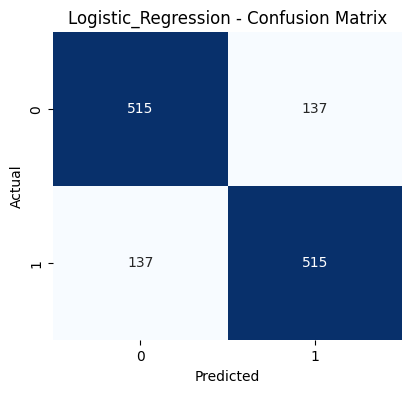

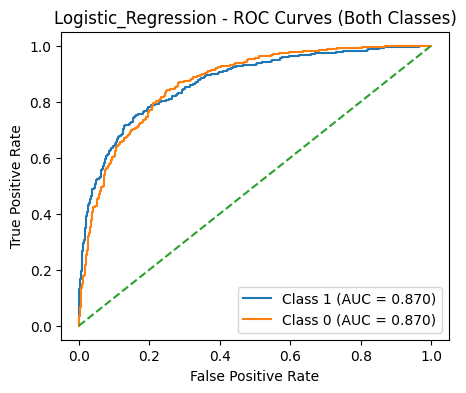

Logistic Regression (Pipeline 1) accuracy: 0.7898773006134969


In [9]:
def logistic_regression_classifier(
    train_df,
    test_df,
    target_col,
    pipeline_name="pipeline_original",
    outdir=OUTDIR,
):
    """
    Train a Logistic Regression classifier on train_df and evaluate on test_df.
    Saves under: <outdir>/<pipeline_name>/Logistic_Regression/
    Returns a dict with accuracy and report paths.
    """
    model_name = "Logistic_Regression"
    model_dir = Path(outdir) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) Split X/y
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].astype(int)

    # 2) Logistic Regression with sensible defaults
    clf = LogisticRegression(
        solver="liblinear",  # works well for binary classification
        random_state=SEED,
        max_iter=1000
    )
    clf.fit(X_train, y_train)

    # 3) Predictions
    y_pred  = clf.predict(X_test)
    proba   = clf.predict_proba(X_test)
    y_score1 = proba[:, 1]   # class 1 scores
    y_score0 = proba[:, 0]   # class 0 scores

    # 4) Metrics
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision & F1 (TPR/TNR computed manually)
    prec, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    # Confusion matrix for counts (labels=[0,1] -> [[TN, FP],[FN, TP]])
    cm_eval = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
    FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

    # Treat class 0 as "positive" for class-0 metrics
    TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
    FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

    def safe_div(n, d): 
        return float(n) / d if d else 0.0

    # TPR (Sensitivity) and TNR (Specificity) per class
    tpr0 = safe_div(TP0, TP0 + FN0)
    tnr0 = safe_div(TN0, TN0 + FP0)
    tpr1 = safe_div(TP1, TP1 + FN1)
    tnr1 = safe_div(TN1, TN1 + FP1)

    # Cohen's Kappa (manual)
    N = cm_eval.sum()
    po = acc
    r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
    c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
    pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
    kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

    # AUCs (each class treated as positive)
    auc1 = roc_auc_score(y_test, y_score1)       # AUC - class 1
    auc0 = roc_auc_score(1 - y_test, y_score0)   # AUC - class 0

    metrics_df = pd.DataFrame({
        "metric": [
            # Overall
            "Accuracy",
            "Cohen's Kappa",

            # Class 0 counts
            "True Positive (TP) - class 0",
            "True Negative (TN) - class 0",
            "False Positive (FP) - class 0",
            "False Negative (FN) - class 0",
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0",
            "True Negative Rate (TNR) / Specificity - class 0",
            "Precision - class 0",
            "F1 Score - class 0",

            # Class 1 counts
            "True Positive (TP) - class 1",
            "True Negative (TN) - class 1",
            "False Positive (FP) - class 1",
            "False Negative (FN) - class 1",
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1",
            "True Negative Rate (TNR) / Specificity - class 1",
            "Precision - class 1",
            "F1 Score - class 1",

            # AUCs (ROC curve plotted separately)
            "AUC - class 0",
            "AUC - class 1",
        ],
        "value": [
            acc,
            kappa,

            # Class 0 counts
            TP0, TN0, FP0, FN0,
            # Class 0 rates/metrics
            tpr0, tnr0, prec[0], f1[0],

            # Class 1 counts
            TP1, TN1, FP1, FN1,
            # Class 1 rates/metrics
            tpr1, tnr1, prec[1], f1[1],

            # AUCs
            auc0, auc1,
        ]
    })
    metrics_csv = model_dir / "metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    # classification report
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y_test, y_pred, digits=4))

    # 5) Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    cm_jpg = model_dir / "confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # 6) ROC curve (both classes)
    fpr1, tpr1, _ = roc_curve(y_test, y_score1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y_test, y_score0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "model": clf,
        "accuracy": acc,
        "metrics_csv": str(metrics_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
    }

# Usage: Pipeline 1 (original dataset)
logreg_out = logistic_regression_classifier(
    train_scaled,
    test_scaled,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_original_data"
)
print("Logistic Regression (Pipeline 1) accuracy:", logreg_out["accuracy"])

Random Forest

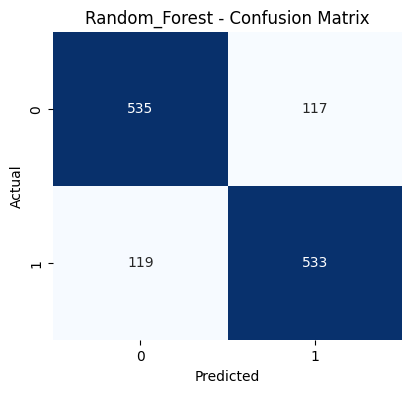

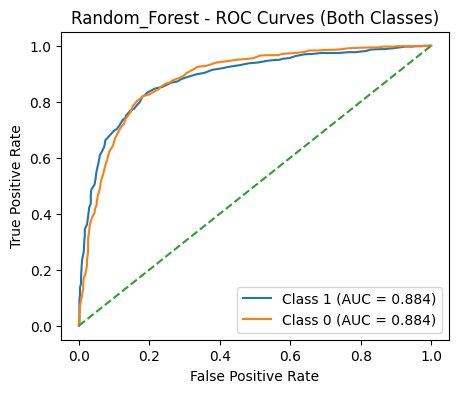

Random Forest (Pipeline 1) accuracy: 0.8190184049079755


In [10]:
def random_forest_classifier(
    train_df,
    test_df,
    target_col,
    pipeline_name="pipeline_original",
    outdir=OUTDIR,
):
    """
    Train a Random Forest classifier on train_df and evaluate on test_df.
    Saves under: <outdir>/<pipeline_name>/Random_Forest/
    Returns a dict with accuracy and report paths.
    """
    model_name = "Random_Forest"
    model_dir = Path(outdir) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) Split X/y
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].astype(int)

    # 2) Random Forest
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    # 3) Predictions
    y_pred  = clf.predict(X_test)
    proba   = clf.predict_proba(X_test)
    y_score1 = proba[:, 1]  # class 1 scores
    y_score0 = proba[:, 0]  # class 0 scores

    # 4) Metrics
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision & F1 (compute TPR/TNR)
    prec, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    # Confusion matrix for counts (labels=[0,1] -> [[TN, FP],[FN, TP]])
    cm_eval = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
    FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

    # Treat class 0 as "positive" for class-0 metrics
    TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
    FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

    def safe_div(n, d): 
        return float(n) / d if d else 0.0

    # TPR (Sensitivity) and TNR (Specificity) per class
    tpr0 = safe_div(TP0, TP0 + FN0)
    tnr0 = safe_div(TN0, TN0 + FP0)
    tpr1 = safe_div(TP1, TP1 + FN1)
    tnr1 = safe_div(TN1, TN1 + FP1)

    # Cohen's Kappa (manual)
    N = cm_eval.sum()
    po = acc
    r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
    c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
    pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
    kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

    # AUCs (each class treated as positive)
    auc1 = roc_auc_score(y_test, y_score1)       # AUC - class 1
    auc0 = roc_auc_score(1 - y_test, y_score0)   # AUC - class 0

    metrics_df = pd.DataFrame({
        "metric": [
            # Overall
            "Accuracy",
            "Cohen's Kappa",

            # Class 0 counts
            "True Positive (TP) - class 0",
            "True Negative (TN) - class 0",
            "False Positive (FP) - class 0",
            "False Negative (FN) - class 0",
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0",
            "True Negative Rate (TNR) / Specificity - class 0",
            "Precision - class 0",
            "F1 Score - class 0",

            # Class 1 counts
            "True Positive (TP) - class 1",
            "True Negative (TN) - class 1",
            "False Positive (FP) - class 1",
            "False Negative (FN) - class 1",
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1",
            "True Negative Rate (TNR) / Specificity - class 1",
            "Precision - class 1",
            "F1 Score - class 1",

            # AUCs (ROC curve plotted separately)
            "AUC - class 0",
            "AUC - class 1",
        ],
        "value": [
            acc,
            kappa,

            # Class 0 counts
            TP0, TN0, FP0, FN0,
            # Class 0 rates/metrics
            tpr0, tnr0, prec[0], f1[0],

            # Class 1 counts
            TP1, TN1, FP1, FN1,
            # Class 1 rates/metrics
            tpr1, tnr1, prec[1], f1[1],

            # AUCs
            auc0, auc1,
        ]
    })
    metrics_csv = model_dir / "metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    # classification report
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y_test, y_pred, digits=4))

    # 5) Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    cm_jpg = model_dir / "confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # 6) ROC curve (both classes)
    fpr1, tpr1, _ = roc_curve(y_test, y_score1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y_test, y_score0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "model": clf,
        "accuracy": acc,
        "metrics_csv": str(metrics_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
    }

# Usage: Pipeline 1 (original dataset, unscaled train/test)
rf_out = random_forest_classifier(
    train_df,
    test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_original_data"
)
print("Random Forest (Pipeline 1) accuracy:", rf_out["accuracy"])


LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2608, number of negative: 2608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3417
[LightGBM] [Info] Number of data points in the train set: 5216, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


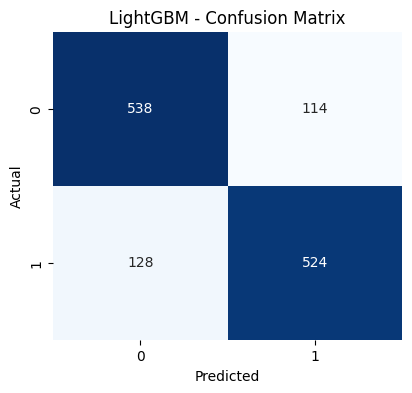

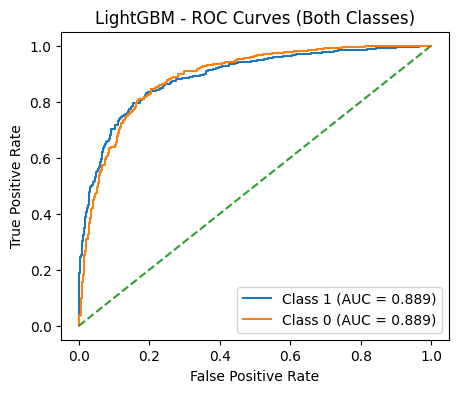

LightGBM (Pipeline 1) accuracy: 0.8144171779141104


In [11]:
def lightgbm_classifier(
    train_df,
    test_df,
    target_col,
    pipeline_name="pipeline_original",
    outdir=OUTDIR,
):
    """
    Train a LightGBM classifier on train_df and evaluate on test_df.
    Saves under: <outdir>/<pipeline_name>/LightGBM/
    Returns a dict with accuracy and report paths.
    """
    model_name = "LightGBM"
    model_dir = Path(outdir) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) Split X/y
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].astype(int)

    # 2) LightGBM model
    clf = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=SEED,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    # 3) Predictions
    y_pred  = clf.predict(X_test)
    proba   = clf.predict_proba(X_test)
    y_score1 = proba[:, 1]   # class 1 scores
    y_score0 = proba[:, 0]   # class 0 scores

    # 4) Metrics
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision & F1 (TPR/TNR computed manually)
    prec, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    # Confusion matrix for counts (labels=[0,1] -> [[TN, FP],[FN, TP]])
    cm_eval = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
    FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

    # Treat class 0 as "positive" for class-0 metrics
    TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
    FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

    def safe_div(n, d):
        return float(n) / d if d else 0.0

    # TPR (Sensitivity) and TNR (Specificity) per class
    tpr0 = safe_div(TP0, TP0 + FN0)
    tnr0 = safe_div(TN0, TN0 + FP0)
    tpr1 = safe_div(TP1, TP1 + FN1)
    tnr1 = safe_div(TN1, TN1 + FP1)

    # Cohen's Kappa (manual)
    N = cm_eval.sum()
    po = acc
    r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
    c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
    pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
    kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

    # AUCs (each class treated as positive)
    auc1 = roc_auc_score(y_test, y_score1)       # AUC - class 1
    auc0 = roc_auc_score(1 - y_test, y_score0)   # AUC - class 0

    metrics_df = pd.DataFrame({
        "metric": [
            # Overall
            "Accuracy",
            "Cohen's Kappa",

            # Class 0 counts
            "True Positive (TP) - class 0",
            "True Negative (TN) - class 0",
            "False Positive (FP) - class 0",
            "False Negative (FN) - class 0",
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0",
            "True Negative Rate (TNR) / Specificity - class 0",
            "Precision - class 0",
            "F1 Score - class 0",

            # Class 1 counts
            "True Positive (TP) - class 1",
            "True Negative (TN) - class 1",
            "False Positive (FP) - class 1",
            "False Negative (FN) - class 1",
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1",
            "True Negative Rate (TNR) / Specificity - class 1",
            "Precision - class 1",
            "F1 Score - class 1",

            # AUCs (ROC curve plotted separately)
            "AUC - class 0",
            "AUC - class 1",
        ],
        "value": [
            acc,
            kappa,

            # Class 0 counts
            TP0, TN0, FP0, FN0,
            # Class 0 rates/metrics
            tpr0, tnr0, prec[0], f1[0],

            # Class 1 counts
            TP1, TN1, FP1, FN1,
            # Class 1 rates/metrics
            tpr1, tnr1, prec[1], f1[1],

            # AUCs
            auc0, auc1,
        ]
    })
    metrics_csv = model_dir / "metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    # classification report
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y_test, y_pred, digits=4))

    # 5) Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    cm_jpg = model_dir / "confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # 6) ROC curve (both classes)
    fpr1, tpr1, _ = roc_curve(y_test, y_score1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y_test, y_score0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "model": clf,
        "accuracy": acc,
        "metrics_csv": str(metrics_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
    }

# Usage: Pipeline 1 (original dataset, unscaled train/test)
lgbm_out = lightgbm_classifier(
    train_df,
    test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_original_data"
)
print("LightGBM (Pipeline 1) accuracy:", lgbm_out["accuracy"])

CatBoost

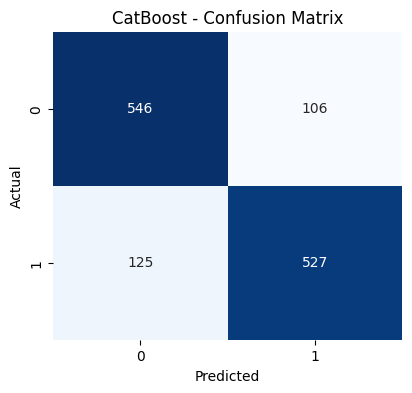

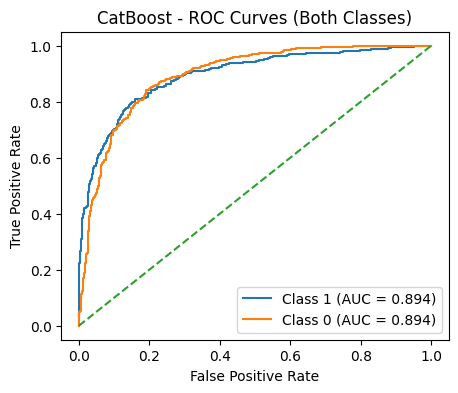

CatBoost (Pipeline 1) accuracy: 0.8228527607361963


In [12]:
def catboost_classifier(
    train_df,
    test_df,
    target_col,
    pipeline_name="pipeline_original",
    outdir=OUTDIR,
):
    """
    Train a CatBoost classifier on train_df (unscaled) and evaluate on test_df.
    Saves under: <outdir>/<pipeline_name>/CatBoost/
    Returns a dict with accuracy and report paths.
    """
    model_name = "CatBoost"
    model_dir = Path(outdir) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) Split X/y
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].astype(int)

    # 2) Model (sensible defaults, silent training)
    clf = CatBoostClassifier(
        depth=6,
        learning_rate=0.1,
        n_estimators=300,
        loss_function="Logloss",
        random_seed=SEED,
        eval_metric="AUC",
        verbose=False
    )
    clf.fit(X_train, y_train)

    # 3) Predictions
    y_pred  = clf.predict(X_test).astype(int)
    proba   = clf.predict_proba(X_test)
    y_score1 = proba[:, 1]   # class 1 scores
    y_score0 = proba[:, 0]   # class 0 scores

    # 4) Metrics
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision & F1 (TPR/TNR computed manually)
    prec, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    # Confusion matrix for counts (labels=[0,1] -> [[TN, FP],[FN, TP]])
    cm_eval = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
    FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

    # Treat class 0 as "positive" for class-0 metrics
    TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
    FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

    def safe_div(n, d):
        return float(n) / d if d else 0.0

    # TPR (Sensitivity) and TNR (Specificity) per class
    tpr0 = safe_div(TP0, TP0 + FN0)
    tnr0 = safe_div(TN0, TN0 + FP0)
    tpr1 = safe_div(TP1, TP1 + FN1)
    tnr1 = safe_div(TN1, TN1 + FP1)

    # Cohen's Kappa (manual)
    N = cm_eval.sum()
    po = acc
    r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
    c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
    pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
    kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

    # AUCs (each class treated as positive)
    auc1 = roc_auc_score(y_test, y_score1)       # AUC - class 1
    auc0 = roc_auc_score(1 - y_test, y_score0)   # AUC - class 0

    metrics_df = pd.DataFrame({
        "metric": [
            # Overall
            "Accuracy",
            "Cohen's Kappa",

            # Class 0 counts
            "True Positive (TP) - class 0",
            "True Negative (TN) - class 0",
            "False Positive (FP) - class 0",
            "False Negative (FN) - class 0",
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0",
            "True Negative Rate (TNR) / Specificity - class 0",
            "Precision - class 0",
            "F1 Score - class 0",

            # Class 1 counts
            "True Positive (TP) - class 1",
            "True Negative (TN) - class 1",
            "False Positive (FP) - class 1",
            "False Negative (FN) - class 1",
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1",
            "True Negative Rate (TNR) / Specificity - class 1",
            "Precision - class 1",
            "F1 Score - class 1",

            # AUCs (ROC curve plotted separately)
            "AUC - class 0",
            "AUC - class 1",
        ],
        "value": [
            acc,
            kappa,

            # Class 0 counts
            TP0, TN0, FP0, FN0,
            # Class 0 rates/metrics
            tpr0, tnr0, prec[0], f1[0],

            # Class 1 counts
            TP1, TN1, FP1, FN1,
            # Class 1 rates/metrics
            tpr1, tnr1, prec[1], f1[1],

            # AUCs
            auc0, auc1,
        ]
    })
    metrics_csv = model_dir / "metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    # classification report
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y_test, y_pred, digits=4))

    # 5) Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    cm_jpg = model_dir / "confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # 6) ROC curve (both classes)
    fpr1, tpr1, _ = roc_curve(y_test, y_score1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y_test, y_score0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "model": clf,
        "accuracy": acc,
        "metrics_csv": str(metrics_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
    }

# Usage: Pipeline 1 (original dataset, unscaled train/test)
cb_out = catboost_classifier(
    train_df,
    test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_original_data"
)
print("CatBoost (Pipeline 1) accuracy:", cb_out["accuracy"])


XGBoost

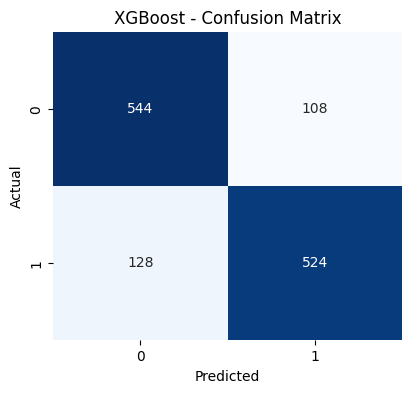

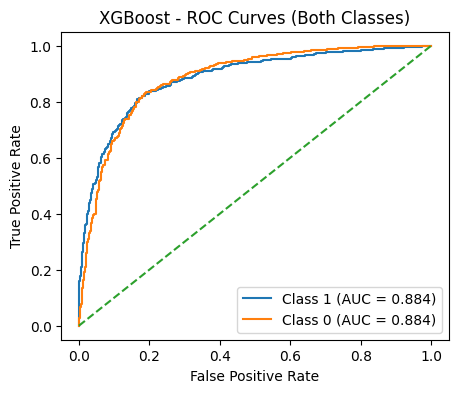

XGBoost (Pipeline 1) accuracy: 0.8190184049079755


In [13]:
def xgboost_classifier(
    train_df,
    test_df,
    target_col,
    pipeline_name="pipeline_original",
    outdir=OUTDIR,
):
    """
    Train an XGBoost classifier on train_df (unscaled) and evaluate on test_df.
    Saves under: <outdir>/<pipeline_name>/XGBoost/
    Returns a dict with accuracy and report paths.
    """
    model_name = "XGBoost"
    model_dir = Path(outdir) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) Split X/y
    X_train_full = train_df.drop(columns=[target_col])
    y_train_full = train_df[target_col].astype(int)
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].astype(int)

    # internal validation split (no test leakage)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=0.2,
        stratify=y_train_full,
        random_state=SEED
    )

    # 2) Model
    clf = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",      # use AUC for early stopping
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )

    # Fit with early stopping on validation set
    try:
        clf.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False,
            early_stopping_rounds=30
        )
    except TypeError:
        try:
            from xgboost.callback import EarlyStopping
            clf.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False,
                callbacks=[EarlyStopping(rounds=30, save_best=True, maximize=True)]
            )
        except Exception:
            clf.fit(X_train, y_train, verbose=False)

    # 3) Predictions on untouched test set
    y_pred  = clf.predict(X_test)
    proba   = clf.predict_proba(X_test)
    y_score1 = proba[:, 1]   # class 1 scores
    y_score0 = proba[:, 0]   # class 0 scores

    # 4) Metrics
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision & F1 (TPR/TNR computed manually)
    prec, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    # Confusion matrix for counts (labels=[0,1] -> [[TN, FP],[FN, TP]])
    cm_eval = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
    FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

    # Treat class 0 as "positive" for class-0 metrics
    TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
    FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

    def safe_div(n, d):
        return float(n) / d if d else 0.0

    # TPR (Sensitivity) and TNR (Specificity) per class
    tpr0 = safe_div(TP0, TP0 + FN0)
    tnr0 = safe_div(TN0, TN0 + FP0)
    tpr1 = safe_div(TP1, TP1 + FN1)
    tnr1 = safe_div(TN1, TN1 + FP1)

    # Cohen's Kappa (manual)
    N = cm_eval.sum()
    po = acc
    r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
    c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
    pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
    kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

    # AUCs (each class treated as positive)
    auc1 = roc_auc_score(y_test, y_score1)       # AUC - class 1
    auc0 = roc_auc_score(1 - y_test, y_score0)   # AUC - class 0

    metrics_df = pd.DataFrame({
        "metric": [
            # Overall
            "Accuracy",
            "Cohen's Kappa",

            # Class 0 counts
            "True Positive (TP) - class 0",
            "True Negative (TN) - class 0",
            "False Positive (FP) - class 0",
            "False Negative (FN) - class 0",
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0",
            "True Negative Rate (TNR) / Specificity - class 0",
            "Precision - class 0",
            "F1 Score - class 0",

            # Class 1 counts
            "True Positive (TP) - class 1",
            "True Negative (TN) - class 1",
            "False Positive (FP) - class 1",
            "False Negative (FN) - class 1",
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1",
            "True Negative Rate (TNR) / Specificity - class 1",
            "Precision - class 1",
            "F1 Score - class 1",

            # AUCs (ROC curve plotted separately)
            "AUC - class 0",
            "AUC - class 1",
        ],
        "value": [
            acc,
            kappa,

            # Class 0 counts
            TP0, TN0, FP0, FN0,
            # Class 0 rates/metrics
            tpr0, tnr0, prec[0], f1[0],

            # Class 1 counts
            TP1, TN1, FP1, FN1,
            # Class 1 rates/metrics
            tpr1, tnr1, prec[1], f1[1],

            # AUCs
            auc0, auc1,
        ]
    })
    metrics_csv = model_dir / "metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    # classification report
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y_test, y_pred, digits=4))

    # 5) Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    cm_jpg = model_dir / "confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # 6) ROC curve (both classes)
    fpr1, tpr1, _ = roc_curve(y_test, y_score1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y_test, y_score0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "model": clf,
        "accuracy": acc,
        "metrics_csv": str(metrics_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
    }

# Usage: Pipeline 1 (original dataset, unscaled train/test)
xgb_out = xgboost_classifier(
    train_df,
    test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_original_data"
)
print("XGBoost (Pipeline 1) accuracy:", xgb_out["accuracy"])


CNN

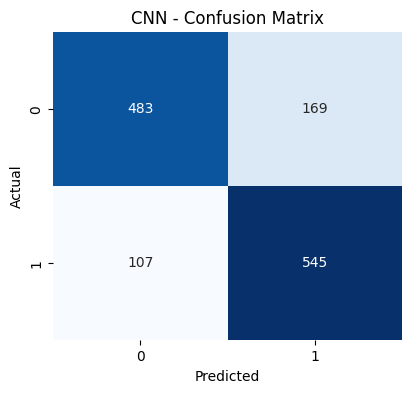

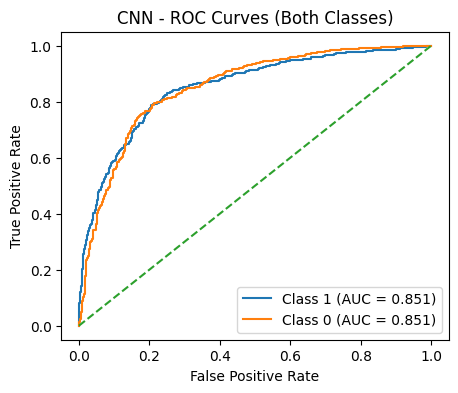

CNN (Pipeline 1) accuracy: 0.7883435582822086


In [14]:
def cnn_classifier(
    train_scaled: pd.DataFrame,
    test_scaled: pd.DataFrame,
    target_col: str,
    pipeline_name: str = "pipeline_original_data",
    outdir: Path = Path("./results"),
    epochs: int = 20,
    batch_size: int = 32,
):
    """
    1D CNN for tabular (already scaled) data. Saves metrics + plots like other models.
    Folder: <outdir>/<pipeline_name>/CNN/
    """
    model_name = "CNN"
    model_dir = Path(outdir) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # Split features/target
    X_train = train_scaled.drop(columns=[target_col]).to_numpy()
    y_train = train_scaled[target_col].astype(int).to_numpy()
    X_test  = test_scaled.drop(columns=[target_col]).to_numpy()
    y_test  = test_scaled[target_col].astype(int).to_numpy()

    # Conv1D expects (samples, timesteps, channels)
    X_train_r = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_r  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

    # One-hot labels for softmax
    y_train_cat = to_categorical(y_train, num_classes=2)
    y_test_cat  = to_categorical(y_test,  num_classes=2)

    # Model
    model = Sequential([
        Input(shape=(X_train_r.shape[1], 1)),
        Conv1D(filters=32, kernel_size=3, activation="relu"),
        Dropout(0.3),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(2, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    # Train
    model.fit(
        X_train_r, y_train_cat,
        validation_data=(X_test_r, y_test_cat),
        epochs=epochs, batch_size=batch_size, verbose=0
    )

    # Predict
    proba   = model.predict(X_test_r, verbose=0)
    y_score1 = proba[:, 1]   # class 1 scores
    y_score0 = proba[:, 0]   # class 0 scores
    y_pred   = (y_score1 >= 0.5).astype(int)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision & F1 (TPR/TNR computed manually)
    prec, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1], zero_division=0
    )

    # Confusion matrix for counts (labels=[0,1] -> [[TN, FP],[FN, TP]])
    cm_eval = confusion_matrix(y_test, y_pred, labels=[0, 1])
    TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
    FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

    # Treat class 0 as "positive" for class-0 metrics
    TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
    FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

    def safe_div(n, d):
        return float(n) / d if d else 0.0

    # TPR (Sensitivity) and TNR (Specificity) per class
    tpr0 = safe_div(TP0, TP0 + FN0)
    tnr0 = safe_div(TN0, TN0 + FP0)
    tpr1 = safe_div(TP1, TP1 + FN1)
    tnr1 = safe_div(TN1, TN1 + FP1)

    # Cohen's Kappa (manual)
    N = cm_eval.sum()
    po = acc
    r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
    c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
    pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
    kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

    # AUCs (each class treated as positive)
    auc1 = roc_auc_score(y_test, y_score1)       # AUC - class 1
    auc0 = roc_auc_score(1 - y_test, y_score0)   # AUC - class 0

    metrics_df = pd.DataFrame({
        "metric": [
            # Overall
            "Accuracy",
            "Cohen's Kappa",

            # Class 0 counts
            "True Positive (TP) - class 0",
            "True Negative (TN) - class 0",
            "False Positive (FP) - class 0",
            "False Negative (FN) - class 0",
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0",
            "True Negative Rate (TNR) / Specificity - class 0",
            "Precision - class 0",
            "F1 Score - class 0",

            # Class 1 counts
            "True Positive (TP) - class 1",
            "True Negative (TN) - class 1",
            "False Positive (FP) - class 1",
            "False Negative (FN) - class 1",
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1",
            "True Negative Rate (TNR) / Specificity - class 1",
            "Precision - class 1",
            "F1 Score - class 1",

            # AUCs (ROC curve plotted separately)
            "AUC - class 0",
            "AUC - class 1",
        ],
        "value": [
            acc,
            kappa,

            # Class 0 counts
            TP0, TN0, FP0, FN0,
            # Class 0 rates/metrics
            tpr0, tnr0, prec[0], f1[0],

            # Class 1 counts
            TP1, TN1, FP1, FN1,
            # Class 1 rates/metrics
            tpr1, tnr1, prec[1], f1[1],

            # AUCs
            auc0, auc1,
        ]
    })
    metrics_csv = model_dir / "metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    # classification report
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y_test, y_pred, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    cm_jpg = model_dir / "confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # ROC curve (both classes)
    fpr1, tpr1, _ = roc_curve(y_test, y_score1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y_test, y_score0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # Save model
    model_path = model_dir / "cnn_model.h5"
    model.save(model_path)

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "model": model,
        "accuracy": acc,
        "metrics_csv": str(metrics_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
        "model_path": str(model_path),
    }

# Usage: Pipeline 1 (scaled data already prepared)
cnn_out = cnn_classifier(
    train_scaled=train_scaled,
    test_scaled=test_scaled,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_original_data",
    outdir=OUTDIR
)
print("CNN (Pipeline 1) accuracy:", cnn_out["accuracy"])


Pipeline 2: Now will be running the same models but with PCA results

PCA helper: fits PCA on scaled training features (target excluded), transforms train/test, names components, appends the target, saves CSVs under <outdir>/<pipeline_name>/dfs, and returns the PCA train/test DataFrames, the fitted PCA object, and PC column names. Call below applies it with n_components=0.95.

In [15]:
def apply_pca_to_train_test(
    train_df,
    test_df,
    target_col,
    outdir,
    pipeline_name="pipeline_pca_data",
    n_components=0.95,
    random_state=SEED
):
    """
    Fit PCA on the scaled train_df (without target), transform both train and test.
    Saves pca_train_df and pca_test_df into <outdir>/<pipeline_name>/dfs/
    Returns the DataFrames + PCA model.
    """
    # 1) Separate features/target
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].reset_index(drop=True)
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].reset_index(drop=True)

    # 2) Fit PCA on train
    pca = PCA(n_components=n_components, random_state=random_state)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    # 3) Wrap back into DataFrames
    pca_cols = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
    pca_train_df = pd.DataFrame(X_train_pca, columns=pca_cols)
    pca_train_df[target_col] = y_train

    pca_test_df = pd.DataFrame(X_test_pca, columns=pca_cols)
    pca_test_df[target_col] = y_test

    # 4) Save to disk
    dfs_dir = Path(outdir) / pipeline_name / "dfs"
    dfs_dir.mkdir(parents=True, exist_ok=True)

    train_path = dfs_dir / "pca_train_df.csv"
    test_path  = dfs_dir / "pca_test_df.csv"
    pca_train_df.to_csv(train_path, index=False)
    pca_test_df.to_csv(test_path, index=False)

    print(f"PCA train/test DataFrames saved to: {dfs_dir}")
    print(f"Explained variance ratio sum: {pca.explained_variance_ratio_.sum():.3f}")

    return pca_train_df, pca_test_df, pca, pca_cols


# USAGE

pca_train_df, pca_test_df, pca_model, pca_cols = apply_pca_to_train_test(
    train_df=train_scaled,
    test_df=test_scaled,
    target_col=TARGET_VARIABLE,
    outdir=OUTDIR,
    pipeline_name="pipeline_pca_data",
    n_components=0.95,
    random_state=SEED,
)


PCA train/test DataFrames saved to: ../All Reports/4. Supervised ML and DL Reports/pipeline_pca_data/dfs
Explained variance ratio sum: 0.950


Neural Network

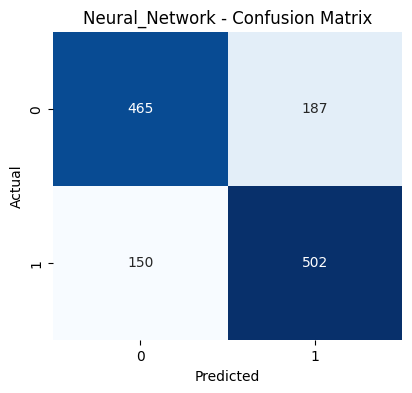

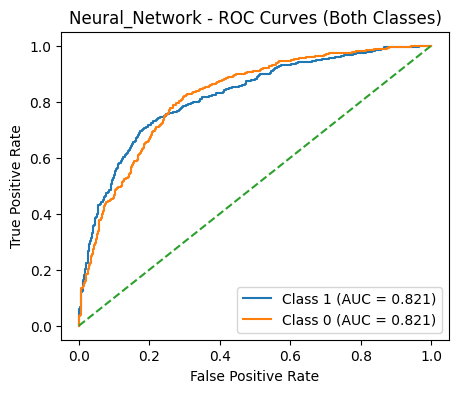

Neural Network (Pipeline 2 - PCA) accuracy: 0.7415644171779141


In [16]:
# Neural Network on PCA-transformed data (Pipeline 2)
nn_pca_out = neural_network_classifier(
    train_df=pca_train_df,
    test_df=pca_test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_pca_data"   # results saved under this folder
)
print("Neural Network (Pipeline 2 - PCA) accuracy:", nn_pca_out["accuracy"])


SVM Polynomial

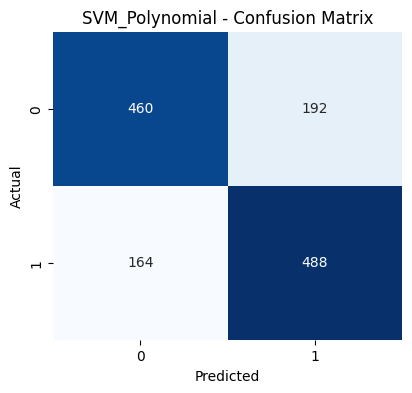

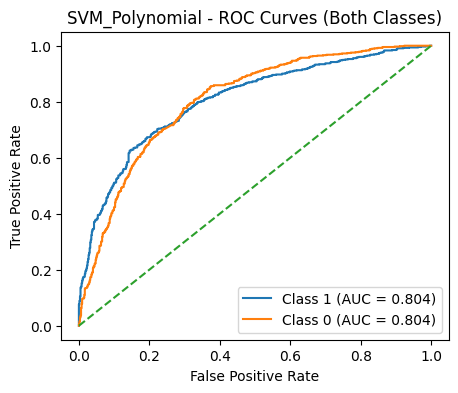

SVM (Pipeline 2 - PCA) accuracy: 0.7269938650306749


In [17]:
# SVM on PCA-transformed data (Pipeline 2)
svm_pca_out = svm_polynomial_classifier(
    train_df=pca_train_df,
    test_df=pca_test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_pca_data"   # results saved under this folder
)
print("SVM (Pipeline 2 - PCA) accuracy:", svm_pca_out["accuracy"])


Logistic Regression

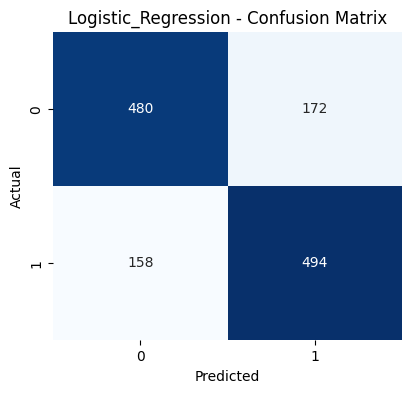

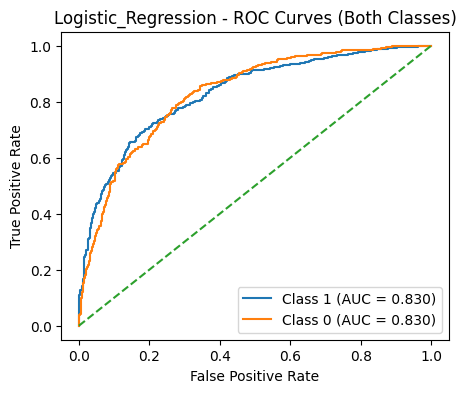

Logistic Regression (Pipeline 2 - PCA) accuracy: 0.7469325153374233


In [18]:
# Logistic Regression on PCA-transformed data (Pipeline 2)
logreg_pca_out = logistic_regression_classifier(
    train_df=pca_train_df,
    test_df=pca_test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_pca_data"   # results saved under this folder
)
print("Logistic Regression (Pipeline 2 - PCA) accuracy:", logreg_pca_out["accuracy"])


Random Forest

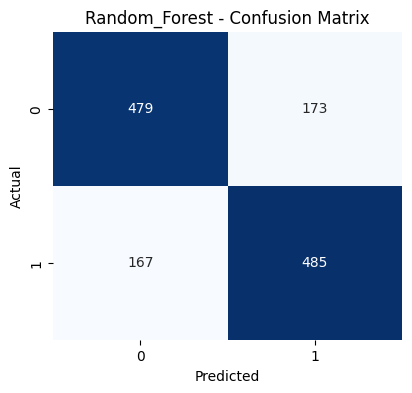

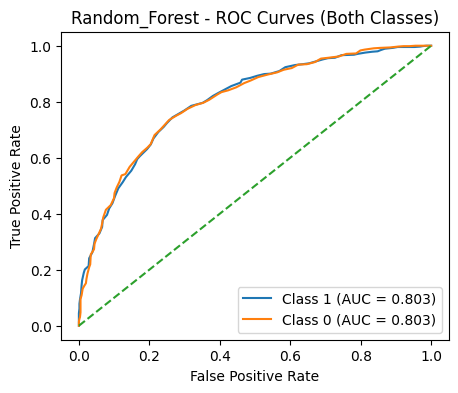

Random Forest (Pipeline 2 - PCA) accuracy: 0.7392638036809815


In [19]:
# Random Forest on PCA-transformed data (Pipeline 2)
rf_pca_out = random_forest_classifier(
    train_df=pca_train_df,
    test_df=pca_test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_pca_data"   # results saved under this folder
)
print("Random Forest (Pipeline 2 - PCA) accuracy:", rf_pca_out["accuracy"])


LightGBM

[LightGBM] [Info] Number of positive: 2608, number of negative: 2608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 5216, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


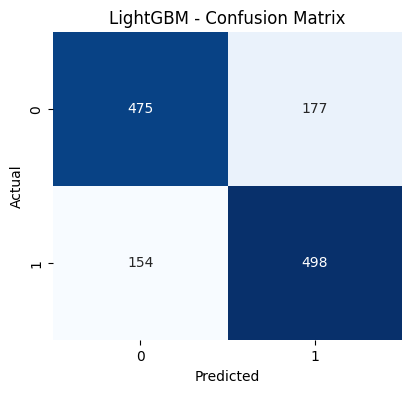

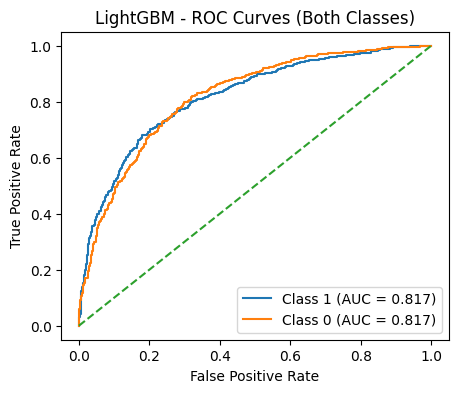

LightGBM (Pipeline 2 - PCA) accuracy: 0.7461656441717791


In [20]:
# LightGBM on PCA-transformed data (Pipeline 2)
lgbm_pca_out = lightgbm_classifier(
    train_df=pca_train_df,
    test_df=pca_test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_pca_data"
)
print("LightGBM (Pipeline 2 - PCA) accuracy:", lgbm_pca_out["accuracy"])


CatBoost

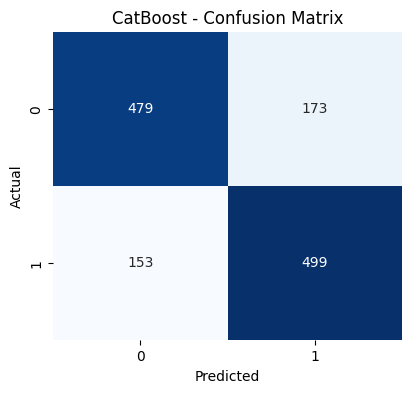

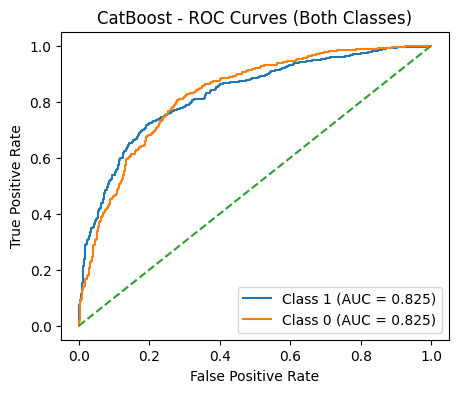

CatBoost (Pipeline 2 - PCA) accuracy: 0.75


In [21]:
# CatBoost on PCA-transformed data (Pipeline 2)
cb_pca_out = catboost_classifier(
    train_df=pca_train_df,
    test_df=pca_test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_pca_data"
)
print("CatBoost (Pipeline 2 - PCA) accuracy:", cb_pca_out["accuracy"])


XGBoost

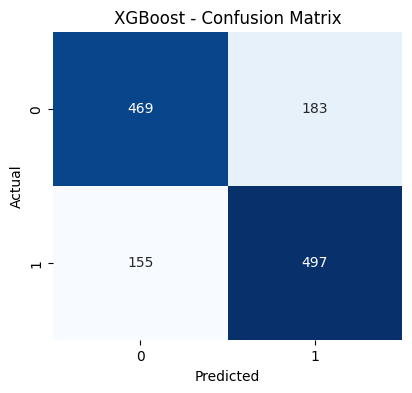

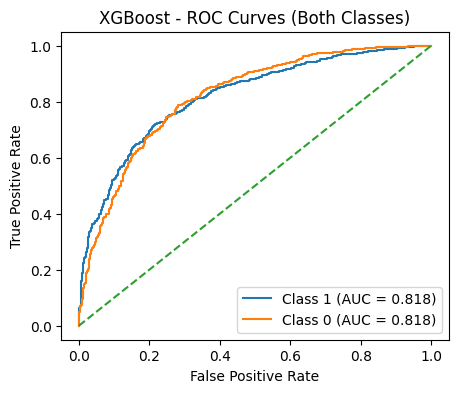

XGBoost (Pipeline 2 - PCA) accuracy: 0.74079754601227


In [22]:
# XGBoost on PCA-transformed data (Pipeline 2)
xgb_pca_out = xgboost_classifier(
    train_df=pca_train_df,
    test_df=pca_test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_pca_data"
)
print("XGBoost (Pipeline 2 - PCA) accuracy:", xgb_pca_out["accuracy"])

CNN

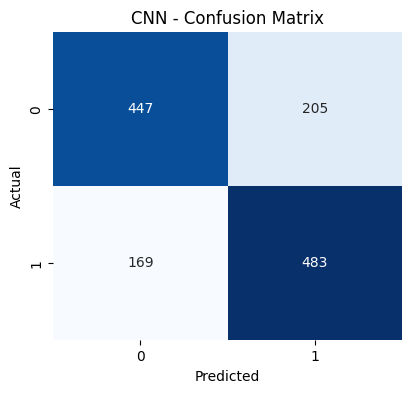

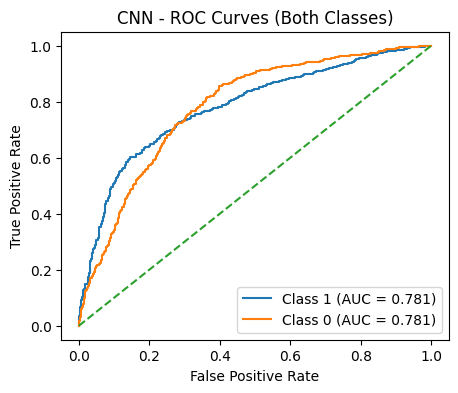

CNN (Pipeline 2 - PCA) accuracy: 0.7131901840490797


In [23]:
# CNN on PCA-transformed data (Pipeline 2)
cnn_pca_out = cnn_classifier(
    train_scaled=pca_train_df,
    test_scaled=pca_test_df,
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_pca_data",
    outdir=OUTDIR
)
print("CNN (Pipeline 2 - PCA) accuracy:", cnn_pca_out["accuracy"])


Pipeline 3: Now will find the top best features and run all the models on them.

Feature-selection pipeline with Random Forest: fit on TRAIN only, rank importances, keep top_k, rebuild train/test with selected features + target, save CSVs and an importance plot, and create scaled variants for distance-sensitive models. Returns selected DataFrames, report paths, and the feature list.

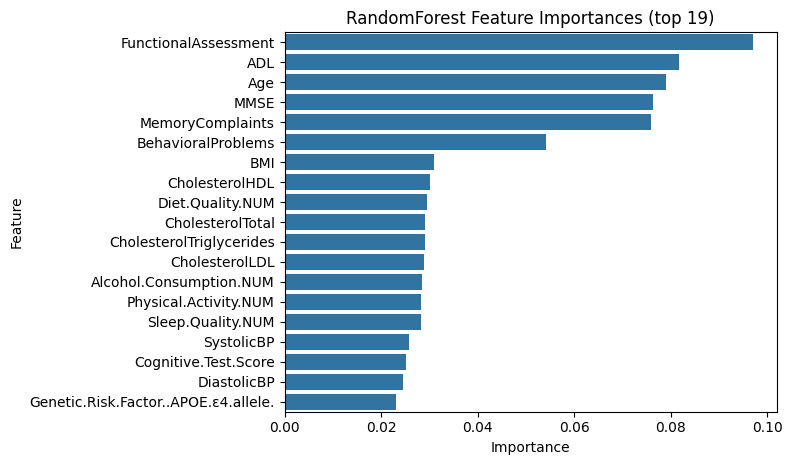

Train shape: (5216, 20), Test shape: (1304, 20)
Scaled columns (standard): ['FunctionalAssessment', 'ADL', 'Age', 'MMSE', 'BMI', 'CholesterolHDL', 'Diet.Quality.NUM', 'CholesterolTotal', 'CholesterolTriglycerides', 'CholesterolLDL', 'Alcohol.Consumption.NUM', 'Physical.Activity.NUM', 'Sleep.Quality.NUM', 'SystolicBP', 'Cognitive.Test.Score', 'DiastolicBP']
Binary columns (not scaled): ['MemoryComplaints', 'BehavioralProblems', 'Genetic.Risk.Factor..APOE.ε4.allele.']

Saved selected feature DataFrames to: ../All Reports/4. Supervised ML and DL Reports/pipeline_features_k19/dfs
Top-19 features: ['FunctionalAssessment', 'ADL', 'Age', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'BMI', 'CholesterolHDL', 'Diet.Quality.NUM', 'CholesterolTotal'] ...


In [24]:
def select_top_features_with_rf(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_col: str,
    top_k: int = 30,
    pipeline_name: str = "pipeline_features_k19",
    outdir: Path = OUTDIR,
    rf_params: dict | None = None,
    scaler_type: str = "standard",
):
    """
    Fit RandomForest on TRAIN ONLY, rank features by importance, select top_k,
    build new train/test DataFrames with those features + target, save CSVs,
    and also create SCALED versions using existing scale_train_test_with_target().

    Returns dict with:
      - 'train_selected', 'test_selected'
      - 'train_selected_scaled', 'test_selected_scaled'
      - 'selected_features', 'feature_importances_csv', 'fi_plot_jpeg'
      - 'train_selected_csv', 'test_selected_csv'
      - 'train_selected_scaled_csv', 'test_selected_scaled_csv'
    """
    # Setup output dirs
    pipe_dir = Path(outdir) / pipeline_name
    dfs_dir  = pipe_dir / "dfs"
    plots_dir = pipe_dir / "plots"
    pipe_dir.mkdir(parents=True, exist_ok=True)
    dfs_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)

    # Split X/y (use TRAIN ONLY to fit RF)
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)

    # Ensure numeric (RF can handle non-scaled, will keep only numbers if any str inside)
    X_train_num = X_train.select_dtypes(include=[np.number])
    # Keep same order subset in test as well
    X_cols = X_train_num.columns.tolist()

    # Default RF params
    if rf_params is None:
        rf_params = dict(
            n_estimators=500,
            max_depth=None,
            random_state=SEED,
            n_jobs=-1,
        )

    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_train_num, y_train)

    # Feature importance ranking
    importances = pd.DataFrame({
        "feature": X_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False, ignore_index=True)

    # Bound top_k
    k = min(top_k, len(importances))
    selected_features = importances["feature"].head(k).tolist()

    # Build selected train/test DataFrames (+ target)
    train_selected = pd.concat(
        [train_df[selected_features], train_df[[target_col]]], axis=1
    )
    # Align test to selected columns
    test_selected = pd.concat(
        [test_df[selected_features], test_df[[target_col]]], axis=1
    )

    # Save selected (unscaled) CSVs
    train_sel_csv = dfs_dir / f"train_selected_top{k}.csv"
    test_sel_csv  = dfs_dir / f"test_selected_top{k}.csv"
    train_selected.to_csv(train_sel_csv, index=False)
    test_selected.to_csv(test_sel_csv, index=False)

    # Save feature importances CSV + bar plot
    fi_csv = dfs_dir / "feature_importances.csv"
    importances.to_csv(fi_csv, index=False)

    plt.figure(figsize=(8, max(3, k * 0.25)))
    sns.barplot(
        data=importances.head(k),
        x="importance", y="feature", orient="h"
    )
    plt.title(f"RandomForest Feature Importances (top {k})")
    plt.xlabel("Importance"); plt.ylabel("Feature")
    fi_jpg = plots_dir / f"feature_importance_top{k}.jpeg"
    plt.tight_layout()
    plt.savefig(fi_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    plt.show()

    # Create SCALED versions for NN/SVM/LogReg/CNN (reuse the function)
    # This uses existing scaler function that leaves 0/1 binaries & target untouched.
    train_selected_scaled, test_selected_scaled, _ = scale_train_test_with_target(
        train_selected, test_selected, target_col=target_col, scaler_type=scaler_type
    )

    train_sel_scaled_csv = dfs_dir / f"train_selected_top{k}_scaled_{scaler_type}.csv"
    test_sel_scaled_csv  = dfs_dir / f"test_selected_top{k}_scaled_{scaler_type}.csv"
    train_selected_scaled.to_csv(train_sel_scaled_csv, index=False)
    test_selected_scaled.to_csv(test_sel_scaled_csv, index=False)

    print(f"\nSaved selected feature DataFrames to: {dfs_dir}")
    print(f"Top-{k} features: {selected_features[:10]}{' ...' if k>10 else ''}")

    return {
        "train_selected": train_selected,
        "test_selected": test_selected,
        "train_selected_scaled": train_selected_scaled,
        "test_selected_scaled": test_selected_scaled,
        "selected_features": selected_features,
        "feature_importances_csv": str(fi_csv),
        "fi_plot_jpeg": str(fi_jpg),
        "train_selected_csv": str(train_sel_csv),
        "test_selected_csv": str(test_sel_csv),
        "train_selected_scaled_csv": str(train_sel_scaled_csv),
        "test_selected_scaled_csv": str(test_sel_scaled_csv),
    }

#Usage (Pipeline 3: Feature-selected)
# Choose k; e.g., top 19
fs_out = select_top_features_with_rf(
    train_df=train_df,                 # Pipeline 1 train split (unscaled)
    test_df=test_df,                   # Pipeline 1 test split (unscaled)
    target_col=TARGET_VARIABLE,
    top_k=19,
    pipeline_name="pipeline_features_k19",
    outdir=OUTDIR,
    scaler_type="standard"
)


Neural Network

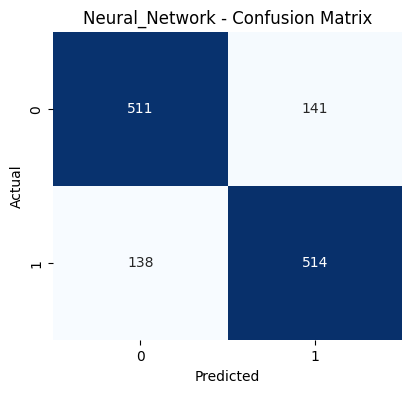

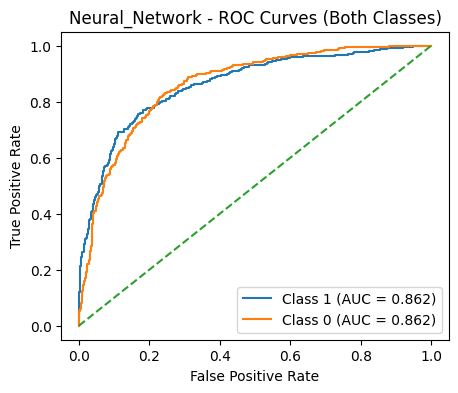

Neural Network (Pipeline 3 - Feature-selected) accuracy: 0.786042944785276


In [25]:
# Neural Network on Feature-selected (Pipeline 3)
nn_fs_out = neural_network_classifier(
    train_df=fs_out["train_selected_scaled"],   # scaled for NN
    test_df=fs_out["test_selected_scaled"],
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_top_features_data"
)
print("Neural Network (Pipeline 3 - Feature-selected) accuracy:", nn_fs_out["accuracy"])

SVM Polynomial

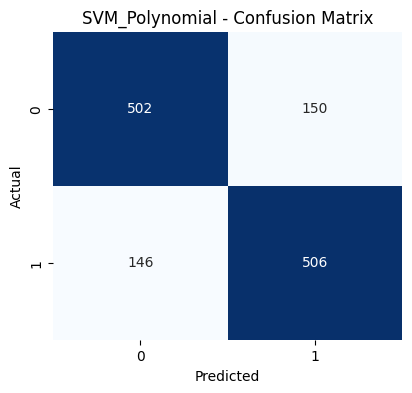

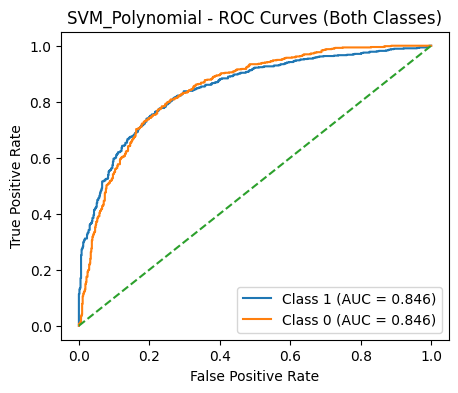

SVM (Pipeline 3 - Feature-selected) accuracy: 0.7730061349693251


In [26]:
# SVM on Feature-selected (Pipeline 3)
svm_fs_out = svm_polynomial_classifier(
    train_df=fs_out["train_selected_scaled"],   # scaled for SVM
    test_df=fs_out["test_selected_scaled"],
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_top_features_data"
)
print("SVM (Pipeline 3 - Feature-selected) accuracy:", svm_fs_out["accuracy"])


Logistic Regression

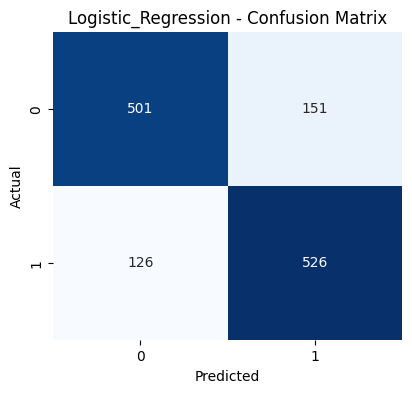

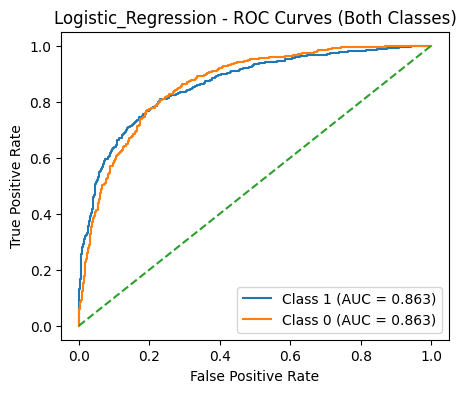

LogReg (Pipeline 3 - Feature-selected) accuracy: 0.7875766871165644


In [27]:
# Logistic Regression on Feature-selected (Pipeline 3)
logreg_fs_out = logistic_regression_classifier(
    train_df=fs_out["train_selected_scaled"],   # scaled for LogReg
    test_df=fs_out["test_selected_scaled"],
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_top_features_data"
)
print("LogReg (Pipeline 3 - Feature-selected) accuracy:", logreg_fs_out["accuracy"])


Random Forest

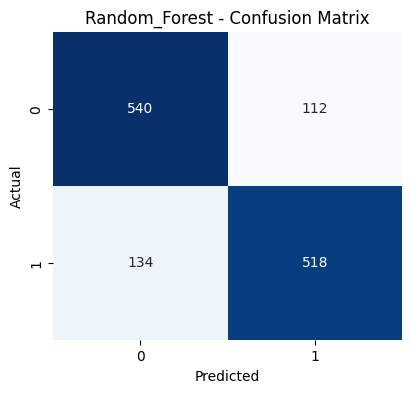

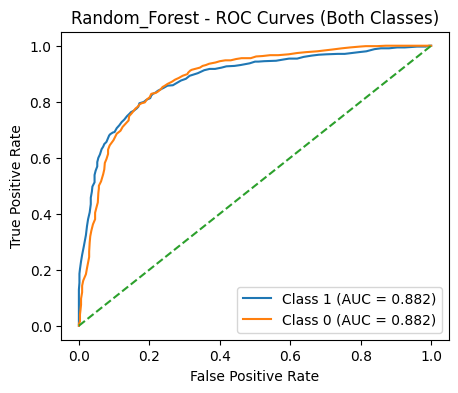

Random Forest (Pipeline 3 - Feature-selected) accuracy: 0.8113496932515337


In [28]:
# Random Forest on Feature-selected (Pipeline 3)
rf_fs_out = random_forest_classifier(
    train_df=fs_out["train_selected"],          # unscaled for RF
    test_df=fs_out["test_selected"],
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_top_features_data"
)
print("Random Forest (Pipeline 3 - Feature-selected) accuracy:", rf_fs_out["accuracy"])


LightGBM

[LightGBM] [Info] Number of positive: 2608, number of negative: 2608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3335
[LightGBM] [Info] Number of data points in the train set: 5216, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


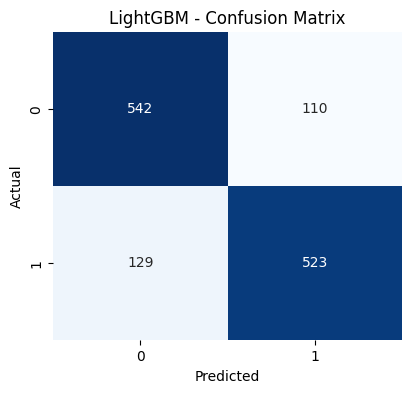

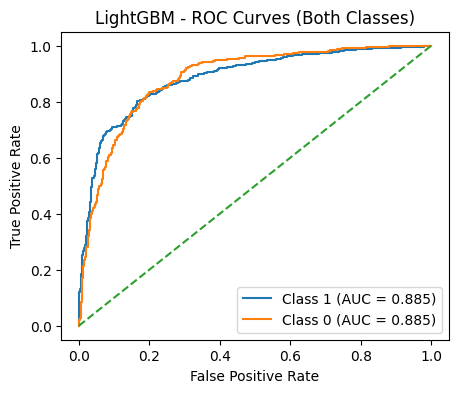

LightGBM (Pipeline 3 - Feature-selected) accuracy: 0.816717791411043


In [29]:
# LightGBM on Feature-selected (Pipeline 3)
lgbm_fs_out = lightgbm_classifier(
    train_df=fs_out["train_selected"],          # unscaled for LGBM
    test_df=fs_out["test_selected"],
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_top_features_data"
)
print("LightGBM (Pipeline 3 - Feature-selected) accuracy:", lgbm_fs_out["accuracy"])


CatBoost

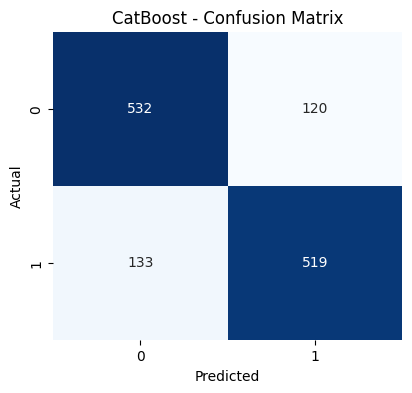

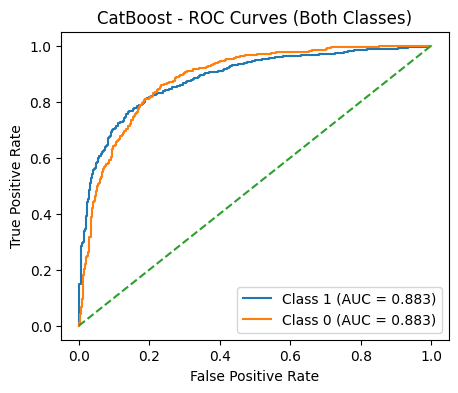

CatBoost (Pipeline 3 - Feature-selected) accuracy: 0.8059815950920245


In [30]:
# CatBoost on Feature-selected (Pipeline 3)
cat_fs_out = catboost_classifier(
    train_df=fs_out["train_selected"],          # unscaled for CatBoost
    test_df=fs_out["test_selected"],
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_top_features_data"
)
print("CatBoost (Pipeline 3 - Feature-selected) accuracy:", cat_fs_out["accuracy"])


XGBoost

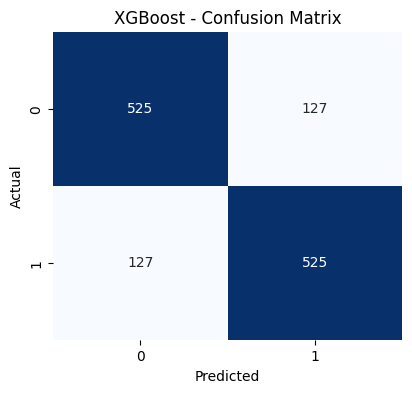

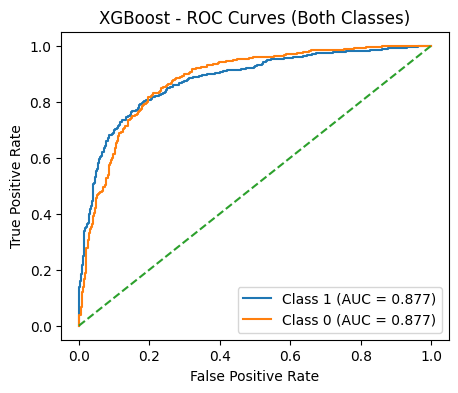

XGBoost (Pipeline 3 - Feature-selected) accuracy: 0.8052147239263804


In [31]:
# XGBoost on Feature-selected (Pipeline 3)
xgb_fs_out = xgboost_classifier(
    train_df=fs_out["train_selected"],          # unscaled for tree models
    test_df=fs_out["test_selected"],
    target_col=TARGET_VARIABLE,
    pipeline_name="pipeline_top_features_data"
)
print("XGBoost (Pipeline 3 - Feature-selected) accuracy:", xgb_fs_out["accuracy"])


CNN

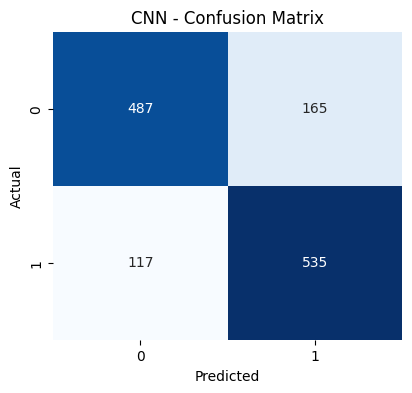

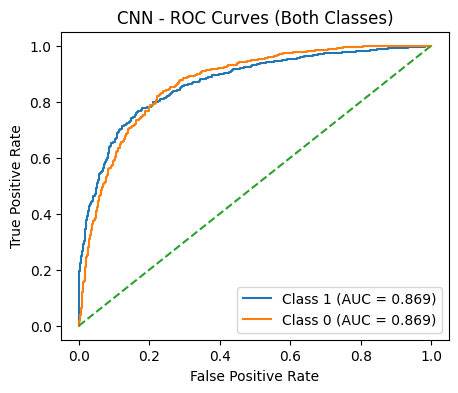

CNN (Pipeline 3 - Feature-selected) accuracy: 0.7837423312883436


In [32]:
# CNN on Feature-selected (Pipeline 3)
cnn_fs_out = cnn_classifier(
    train_scaled=fs_out["train_selected_scaled"],   # scaled for CNN
    test_scaled=fs_out["test_selected_scaled"],
    target_col=TARGET_VARIABLE,
    outdir=OUTDIR,
    pipeline_name="pipeline_top_features_data"
)
print("CNN (Pipeline 3 - Feature-selected) accuracy:", cnn_fs_out["accuracy"])


Collect accuracies from all pipelines/models into one CSV.

In [33]:
def save_accuracy_summary(results_list, outdir=OUTDIR, filename="summary_model_accuracy.csv"):
    """
    Collect accuracies from all pipelines/models into one CSV.
    """
    rows = []
    for res in results_list:
        rows.append({
            "pipeline": res["pipeline"],
            "model_name": res["model_name"],
            "accuracy": res["accuracy"]
        })

    df_summary = pd.DataFrame(rows)
    summary_path = Path(outdir) / filename
    df_summary.to_csv(summary_path, index=False)
    print(f"Summary accuracy table saved to {summary_path}")
    return df_summary


# USAGE
all_results = [
    # Pipeline 1 (Original Data)
    xgb_out, svm_poly_out, nn_out_orig, logreg_out,
    rf_out, lgbm_out, cb_out, cnn_out,

    # Pipeline 2 (PCA)
    xgb_pca_out, svm_pca_out, nn_pca_out, logreg_pca_out,
    rf_pca_out, lgbm_pca_out, cb_pca_out, cnn_pca_out,

    # Pipeline 3 (Feature Selection)
    xgb_fs_out, svm_fs_out, nn_fs_out, logreg_fs_out,
    rf_fs_out, lgbm_fs_out, cat_fs_out, cnn_fs_out,
]

df_summary = save_accuracy_summary(all_results, outdir=OUTDIR_Final)
df_summary


Summary accuracy table saved to ../All Reports/5. All Final Result/summary_model_accuracy.csv


,pipeline,model_name,accuracy
0,pipeline_original_data,XGBoost,0.819018
1,pipeline_original_data,SVM_Polynomial,0.767638
2,pipeline_original_data,Neural_Network,0.782975
3,pipeline_original_data,Logistic_Regression,0.789877
4,pipeline_original_data,Random_Forest,0.819018
5,pipeline_original_data,LightGBM,0.814417
6,pipeline_original_data,CatBoost,0.822853
7,pipeline_original_data,CNN,0.788344
8,pipeline_pca_data,XGBoost,0.740798
9,pipeline_pca_data,SVM_Polynomial,0.726994


Create a grouped bar chart comparing model accuracies across pipelines, with accuracy percentage labels. Saves as JPEG in outdir.

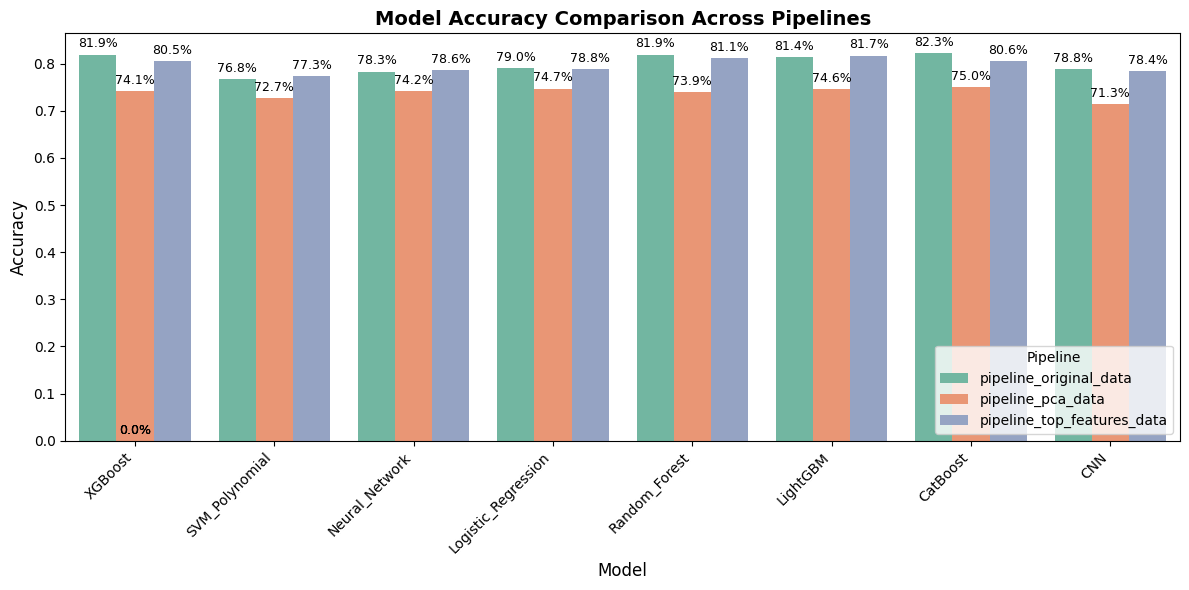

Accuracy comparison chart saved at: ../All Reports/5. All Final Result/accuracy_comparison.jpeg


In [34]:
def plot_accuracy_comparison(df_summary, outdir=OUTDIR_Final, filename="accuracy_comparison.jpeg"):
    """
    Create a grouped bar chart comparing model accuracies across pipelines,
    with accuracy percentage labels. Saves as JPEG in outdir.
    """
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_summary,
        x="model_name", y="accuracy", hue="pipeline",
        palette="Set2"
    )

    # Add percentage labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height*100:.1f}%",   # convert to %
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom",
            fontsize=9, color="black", xytext=(0, 3),
            textcoords="offset points"
        )

    plt.title("Model Accuracy Comparison Across Pipelines", fontsize=14, weight="bold")
    plt.xlabel("Model", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Pipeline")
    plt.tight_layout()

    # Save plot
    outpath = Path(outdir) / filename
    plt.savefig(outpath, format="jpeg", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Accuracy comparison chart saved at: {outpath}")


# USAGE
plot_accuracy_comparison(df_summary)

Top 5 ROC curve according to model accuracy

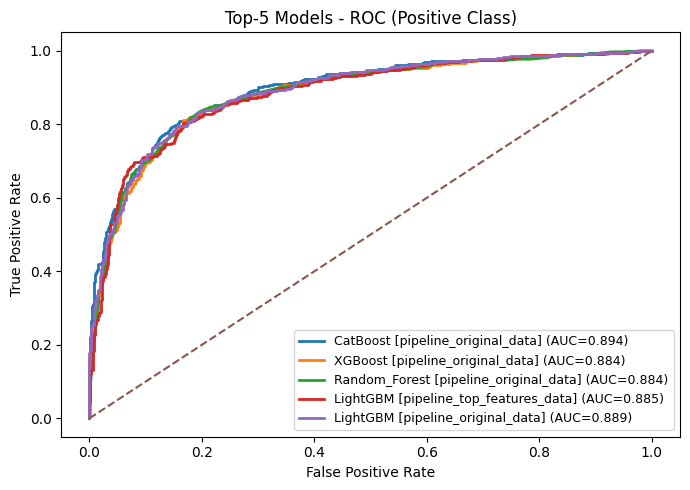

Top-5 combined ROC saved at: ../All Reports/5. All Final Result/top5_roc.jpeg


In [35]:
def _get_test_matrix_for_result(res):
    """
    Returns (X_test, y_test) for a given result dict based on its pipeline & model.
    Uses the globally defined test splits:
      - test_df, test_scaled
      - pca_test_df
      - fs_out["test_selected"], fs_out["test_selected_scaled"]
    """
    model = res["model"]
    pipe  = res["pipeline"]
    name  = res["model_name"]

    if pipe == "pipeline_original_data":
        # distance-based models need scaled data
        if name in {"Neural_Network", "SVM_Polynomial", "Logistic_Regression", "CNN"}:
            X = test_scaled.drop(columns=[TARGET_VARIABLE])
            y = test_scaled[TARGET_VARIABLE].astype(int).values
        else:
            X = test_df.drop(columns=[TARGET_VARIABLE])
            y = test_df[TARGET_VARIABLE].astype(int).values

    elif pipe == "pipeline_pca_data":
        # PCA pipeline already numeric
        X = pca_test_df.drop(columns=[TARGET_VARIABLE])
        y = pca_test_df[TARGET_VARIABLE].astype(int).values

    elif pipe == "pipeline_top_features_data":
        # top-feature pipeline: scaled for distance-based, unscaled for trees
        if name in {"Neural_Network", "SVM_Polynomial", "Logistic_Regression", "CNN"}:
            X = fs_out["test_selected_scaled"].drop(columns=[TARGET_VARIABLE])
            y = fs_out["test_selected_scaled"][TARGET_VARIABLE].astype(int).values
        else:
            X = fs_out["test_selected"].drop(columns=[TARGET_VARIABLE])
            y = fs_out["test_selected"][TARGET_VARIABLE].astype(int).values
    else:
        raise ValueError(f"Unknown pipeline: {pipe}")

    return X, y

def _predict_pos_score(model, X):
    """
    Returns probability scores for positive class (class=1).
    Order of preference:
      1) Keras/TensorFlow .predict
      2) scikit-learn .predict_proba
      3) scikit-learn .decision_function (sigmoid-transformed)
      4) fallback to hard predictions
    """
    # TensorFlow / Keras CNN
    if "keras" in str(type(model)).lower():
        proba = model.predict(X.values.reshape(X.shape[0], X.shape[1], 1), verbose=0)
        return proba[:, 1]

    # scikit-learn style
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        dec = model.decision_function(X)
        if dec.ndim == 1:
            return 1 / (1 + np.exp(-dec))  # sigmoid transform
        return 1 / (1 + np.exp(-dec[:, -1]))

    # fallback: hard predictions
    return model.predict(X).astype(float)

def plot_top5_combined_roc_auto(
    df_summary,
    all_results,
    outdir_final=OUTDIR_Final
):
    """
    Builds a single ROC plot for the top-5 models by accuracy (any pipeline).
    Uses the correct test split automatically per result.
    Saves JPEG to <outdir_final>/top5_roc.jpeg and also displays the plot inline.
    """
    # Select top-5 models
    top5 = df_summary.sort_values("accuracy", ascending=False).head(5).reset_index(drop=True)

    # Build lookup dict (pipeline, model_name) -> trained model result dict
    res_map = {(r["pipeline"], r["model_name"]): r for r in all_results}

    plt.figure(figsize=(7, 5))
    legends = []

    # Loop over top 5 models and plot ROC
    for _, row in top5.iterrows():
        pipe, name = row["pipeline"], row["model_name"]
        res = res_map.get((pipe, name))
        if res is None:
            print(f"[skip] Missing result for {pipe} | {name}")
            continue

        try:
            X, y = _get_test_matrix_for_result(res)
            scores = _predict_pos_score(res["model"], X)
            fpr, tpr, _ = roc_curve(y, scores, pos_label=1)
            auc_val = roc_auc_score(y, scores)

            plt.plot(fpr, tpr, linewidth=2)
            legends.append(f"{name} [{pipe}] (AUC={auc_val:.3f})")
        except Exception as e:
            print(f"[skip] ROC failed for {name} ({pipe}): {e}")

    # Final plot formatting
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Top-5 Models - ROC (Positive Class)")
    plt.legend(legends, loc="lower right", fontsize=9)
    plt.tight_layout()

    # Save + Print
    outpath = Path(outdir_final) / "top5_roc.jpeg"
    plt.savefig(outpath, format="jpeg", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Top-5 combined ROC saved at: {outpath}")

# USAGE
plot_top5_combined_roc_auto(df_summary, all_results, outdir_final=OUTDIR_Final)


Now since that CatBoost gives the best result with the original data, will move forward to do k-fold cross validation with it instead of holdout method.

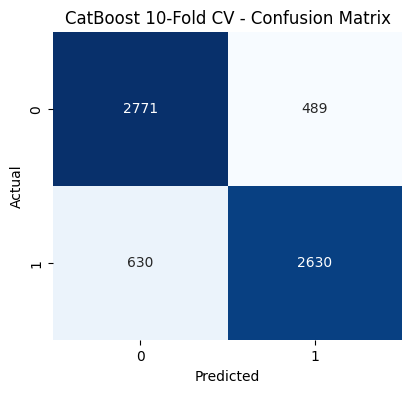

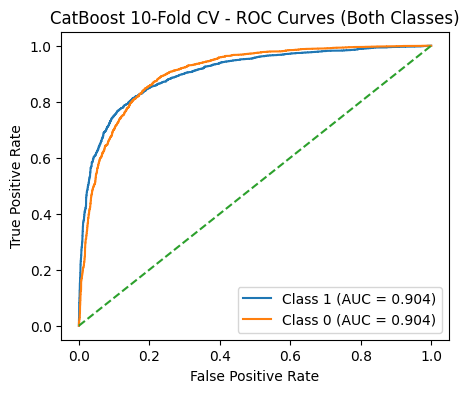

CatBoost 10-Fold CV mean accuracy: 0.8283742331288343


In [36]:
def catboost_cross_validation(
    df: pd.DataFrame,
    target_col: str,
    pipeline_name: str = "CatBoost_CV_Original_data",
    n_splits: int = 10,
    random_state: int = 123,
    outdir_cv: Path = None
):
    """
    10-fold Stratified CV with CatBoost with the same functionality as the other model functions).
    Saves under: <OUTDIR_CV>/<pipeline_name>/CatBoost_CV/
    
    Outputs:
      - cv_metrics.csv (per-fold metrics)
      - cv_summary.csv (mean of metrics)
      - classification_report.txt (on pooled OOF predictions)
      - cv_confusion_matrix.jpeg (pooled OOF predictions @ 0.5 threshold)
      - cv_roc_curve.jpeg (pooled ROC from OOF probabilities)
    """
    if outdir_cv is None:
        outdir_cv = OUTDIR_CV

    model_name = "CatBoost_CV"
    model_dir = Path(outdir_cv) / pipeline_name / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    # Data
    X = df.drop(columns=[target_col])
    y = df[target_col].astype(int).values
    idx = np.arange(len(df))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_metrics = []
    # OOF storage for pooled metrics/plots
    oof_prob1 = np.zeros(len(df), dtype=float)  # prob of class 1
    oof_prob0 = np.zeros(len(df), dtype=float)  # prob of class 0
    oof_pred  = np.zeros(len(df), dtype=int)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_valid = y[train_idx], y[test_idx]

        clf = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            l2_leaf_reg=3,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=random_state,
            verbose=False,
            allow_writing_files=False
        )
        clf.fit(X_train, y_train, eval_set=(X_valid, y_valid), verbose=False)

        proba   = clf.predict_proba(X_valid)
        y_prob1 = proba[:, 1]  # class 1
        y_prob0 = proba[:, 0]  # class 0
        y_hat   = (y_prob1 >= 0.5).astype(int)

        # Store OOF
        oof_prob1[test_idx] = y_prob1
        oof_prob0[test_idx] = y_prob0
        oof_pred[test_idx]  = y_hat

        # Metrics
        acc = accuracy_score(y_valid, y_hat)

        # Per-class precision & F1 (TPR/TNR computed manually)
        prec, _, f1, _ = precision_recall_fscore_support(
            y_valid, y_hat, labels=[0, 1], zero_division=0
        )

        # Confusion matrix for counts (labels=[0,1] -> [[TN, FP],[FN, TP]])
        cm_eval = confusion_matrix(y_valid, y_hat, labels=[0, 1])
        TN1, FP1 = cm_eval[0, 0], cm_eval[0, 1]
        FN1, TP1 = cm_eval[1, 0], cm_eval[1, 1]

        # Treat class 0 as "positive" for class-0 metrics
        TP0, FN0 = cm_eval[0, 0], cm_eval[0, 1]
        FP0, TN0 = cm_eval[1, 0], cm_eval[1, 1]

        def safe_div(n, d):
            return float(n) / d if d else 0.0

        # TPR (Sensitivity) and TNR (Specificity) per class
        tpr0 = safe_div(TP0, TP0 + FN0)
        tnr0 = safe_div(TN0, TN0 + FP0)
        tpr1 = safe_div(TP1, TP1 + FN1)
        tnr1 = safe_div(TN1, TN1 + FP1)

        # Cohen's Kappa (manual)
        N = cm_eval.sum()
        po = acc
        r0, r1 = cm_eval[0, :].sum(), cm_eval[1, :].sum()
        c0, c1 = cm_eval[:, 0].sum(), cm_eval[:, 1].sum()
        pe = safe_div(r0 * c0 + r1 * c1, N * N) if N else 0.0
        kappa = safe_div(po - pe, 1 - pe) if (1 - pe) else 0.0

        # AUCs (each class treated as positive)
        auc1 = roc_auc_score(y_valid, y_prob1)      # AUC - class 1
        auc0 = roc_auc_score(1 - y_valid, y_prob0)  # AUC - class 0

        fold_metrics.append({
            "fold": fold,

            # Overall
            "Accuracy": acc,
            "Cohen's Kappa": kappa,

            # Class 0 counts
            "True Positive (TP) - class 0": TP0,
            "True Negative (TN) - class 0": TN0,
            "False Positive (FP) - class 0": FP0,
            "False Negative (FN) - class 0": FN0,
            # Class 0 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 0": tpr0,
            "True Negative Rate (TNR) / Specificity - class 0": tnr0,
            "Precision - class 0": prec[0],
            "F1 Score - class 0": f1[0],

            # Class 1 counts
            "True Positive (TP) - class 1": TP1,
            "True Negative (TN) - class 1": TN1,
            "False Positive (FP) - class 1": FP1,
            "False Negative (FN) - class 1": FN1,
            # Class 1 rates/metrics
            "True Positive Rate (TPR) / Sensitivity - class 1": tpr1,
            "True Negative Rate (TNR) / Specificity - class 1": tnr1,
            "Precision - class 1": prec[1],
            "F1 Score - class 1": f1[1],

            # AUCs
            "AUC - class 0": auc0,
            "AUC - class 1": auc1,
        })

    # Save metrics
    metrics_df = pd.DataFrame(fold_metrics)
    metrics_csv = model_dir / "cv_metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    summary = metrics_df.mean(numeric_only=True).to_dict()
    summary_csv = model_dir / "cv_summary.csv"
    pd.DataFrame([summary]).to_csv(summary_csv, index=False)

    # Overall (pooled OOF) report
    report_txt = model_dir / "classification_report.txt"
    with open(report_txt, "w") as f:
        f.write(classification_report(y, oof_pred, digits=4))

    # Confusion matrix (pooled OOF)
    cm = confusion_matrix(y, oof_pred, labels=[0,1])
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title("CatBoost 10-Fold CV - Confusion Matrix")
    cm_jpg = model_dir / "cv_confusion_matrix.jpeg"
    plt.savefig(cm_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    # ROC (pooled OOF, both classes)
    auc1_pooled = roc_auc_score(y, oof_prob1)           # class 1 positive
    auc0_pooled = roc_auc_score(1 - y, oof_prob0)       # class 0 positive
    fpr1, tpr1, _ = roc_curve(y, oof_prob1, pos_label=1)
    fpr0, tpr0, _ = roc_curve(y, oof_prob0, pos_label=0)

    plt.figure(figsize=(5,4))
    plt.plot(fpr1, tpr1, label=f"Class 1 (AUC = {auc1_pooled:.3f})")
    plt.plot(fpr0, tpr0, label=f"Class 0 (AUC = {auc0_pooled:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("CatBoost 10-Fold CV - ROC Curves (Both Classes)")
    plt.legend(loc="lower right")
    roc_jpg = model_dir / "cv_roc_curve.jpeg"
    plt.savefig(roc_jpg, format="jpeg", dpi=300, bbox_inches="tight"); plt.show()

    return {
        "model_name": model_name,
        "pipeline": pipeline_name,
        "mean_accuracy": float(summary.get("Accuracy", np.nan)),
        "cv_metrics_csv": str(metrics_csv),
        "cv_summary_csv": str(summary_csv),
        "report_txt": str(report_txt),
        "cm_jpeg": str(cm_jpg),
        "roc_jpeg": str(roc_jpg),
    }

# USAGE (The full original dataset is passed, CV will handle splits internally)
cb_cv_out = catboost_cross_validation(
     df=df,
     target_col=TARGET_VARIABLE,
     pipeline_name="CatBoost_CV_Original_data",
     n_splits=10,
     random_state=SEED,
     outdir_cv=OUTDIR_CV
)
print("CatBoost 10-Fold CV mean accuracy:", cb_cv_out["mean_accuracy"])
